# Notebook 4 - Decision Tree & Random Forest

This notebook develops and evaluates Decision Tree and Random Forest regression models for predicting residential property close prices.

The models are trained using the same chronological, leakage-aware training and testing datasets used for the Linear Regression baseline. Their predictive performance is evaluated using R², MAE, MAPE, MdAPE, and RMSE, and the results are compared against the baseline model.

## Week 5 Summary

- Trained a Decision Tree Regressor to capture nonlinear relationships in property data.
- Evaluated several maximum tree depths and selected the best-performing depth while keeping the remaining hyperparameters fixed.
- Trained a Random Forest Regressor using multiple decision trees to improve predictive stability and reduce model variance.
- Evaluated both models using R², MAE, MAPE, MdAPE, and RMSE.
- Compared model performance against the Linear Regression baseline.
- Visualized the Decision Tree structure and examined model feature importance.
- Considered both predictive accuracy and computational efficiency when selecting model parameters.

## Setup & Load Data

In [1]:
# Data manipulation
import numpy as np
import pandas as pd
from pathlib import Path
# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
# Evaluation
from sklearn.metrics import (r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error)
# Plot
import matplotlib.pyplot as plt

In [2]:
# Number of historical months used for training
TRAIN_MONTHS = 30

In [3]:
# Load csv files into dataframe
data_dir = Path("../data/cleaned_full")
paths = {
    "train_encoded": data_dir / f"train_encoded_{TRAIN_MONTHS}m.csv",
    "test_encoded": data_dir / f"test_encoded_{TRAIN_MONTHS}m.csv",
}
dfs = {
    name: pd.read_csv(path, low_memory = False)
    for name, path in paths.items()
}
train_encoded_df = dfs["train_encoded"]
test_encoded_df = dfs["test_encoded"]
print(f"Training Window: {TRAIN_MONTHS} months")

Training Window: 30 months


In [4]:
print("Training Set shape:", train_encoded_df.shape)
print("Test Set shape:", test_encoded_df.shape)

Training Set shape: (319641, 128)
Test Set shape: (12443, 128)


## Prepare Features and Target

In [5]:
# Training set
x_train = train_encoded_df.drop(columns = ["ClosePrice"])
y_train = train_encoded_df["ClosePrice"]
# Test set
x_test = test_encoded_df.drop(columns = ["ClosePrice"])
y_test = test_encoded_df["ClosePrice"]

In [6]:
print(x_train.shape)
print(x_test.shape)

(319641, 127)
(12443, 127)


## Target Variable Summary

In [7]:
target_summary = y_train.describe().reset_index()
target_summary.columns = ["Statistic", "ClosePrice"]
def format_close_price(row):
    if row["Statistic"] == "count":
        return f"{row['ClosePrice']:,.0f}"
    else:
        return f"${row['ClosePrice']:,.2f}"
target_summary["ClosePrice"] = target_summary.apply(format_close_price, axis = 1)
target_summary.style.hide(axis = "index")

Statistic,ClosePrice
count,"319,641"
mean,"$1,192,999.83"
std,"$948,528.40"
min,"$190,000.00"
25%,"$622,753.00"
50%,"$890,000.00"
75%,"$1,420,000.00"
max,"$8,210,000.00"


## Train Decision Tree Model

### Test different depth of Tree

To identify an appropriate level of model complexity, multiple maximum tree depths were evaluated while keeping the remaining hyperparameters fixed. The configuration with the highest held-out test R² was selected.

For a production workflow, maximum tree depth should be selected using a separate validation period. The current notebook evaluates candidate depths directly on the held-out testing month for exploratory comparison.

In [8]:
# Find the best depth of Tree
depth_results = []
for depth in [3, 5, 8, 10, 12, 15, 20]:
    model = DecisionTreeRegressor(
        max_depth = depth, 
        min_samples_split = 10,
        min_samples_leaf = 5,
        random_state = 42
    )
    model.fit(x_train, y_train)
    y_pred_depth = model.predict(x_test)
    depth_results.append({
        "Max Depth": depth,
        "R²": r2_score(y_test, y_pred_depth),
        "MAE": mean_absolute_error(y_test, y_pred_depth)
    })
depth_results_df = pd.DataFrame(depth_results)
depth_results_df.style.format({
    "R²": "{:.4f}",
    "MAE": "${:,.2f}"
}).hide(axis = "index")

Max Depth,R²,MAE
3,0.4105,"$497,436.21"
5,0.5208,"$415,168.15"
8,0.6607,"$328,801.25"
10,0.7304,"$287,447.20"
12,0.7773,"$254,286.44"
15,0.8117,"$223,561.64"
20,0.8198,"$208,838.71"


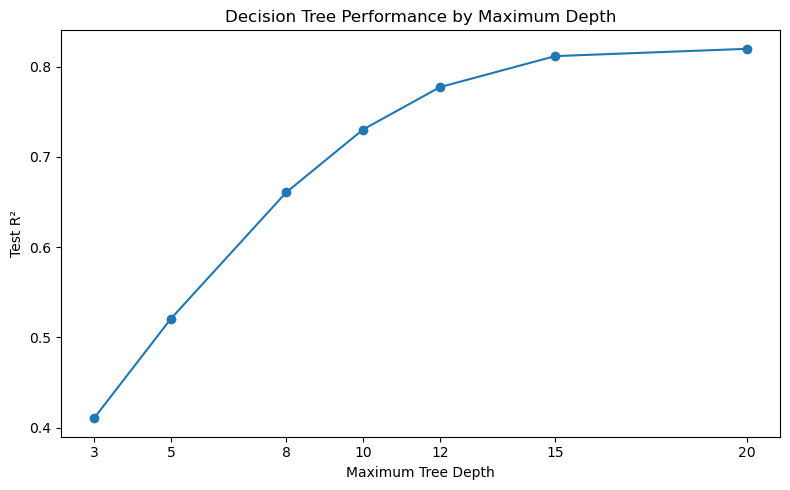

In [9]:
plt.figure(figsize = (8, 5))
plt.plot(depth_results_df["Max Depth"], depth_results_df["R²"], marker = "o")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Test R²")
plt.title("Decision Tree Performance by Maximum Depth")
plt.xticks(depth_results_df["Max Depth"])
plt.tight_layout()
plt.show()

Decision Tree performance generally improved as the maximum depth increased, although the gains became smaller at greater depths. The configuration with the highest validation R² was selected for the final model.

In [10]:
best_depth = int(depth_results_df.loc[depth_results_df["R²"].idxmax(), "Max Depth"])
print(f"Best max depth based on test R²: {best_depth}")

Best max depth based on test R²: 20


### Rerun the Decision Tree model

In [11]:
# Initialize Decision Tree Model with the best_depth we found
dt_regressor = DecisionTreeRegressor(
    max_depth = best_depth, 
    min_samples_split = 10,
    min_samples_leaf = 5,
    random_state = 42
)
dt_regressor.fit(x_train, y_train)
print("Decision Tree training completed.")

Decision Tree training completed.


## Generate Predictions

In [12]:
y_pred_dt = dt_regressor.predict(x_test)

## Decision Tree Visualization

The first three levels of the trained Decision Tree are visualized below.  
Only the upper levels are displayed to preserve readability because the complete tree contains a large number of nodes and branches.

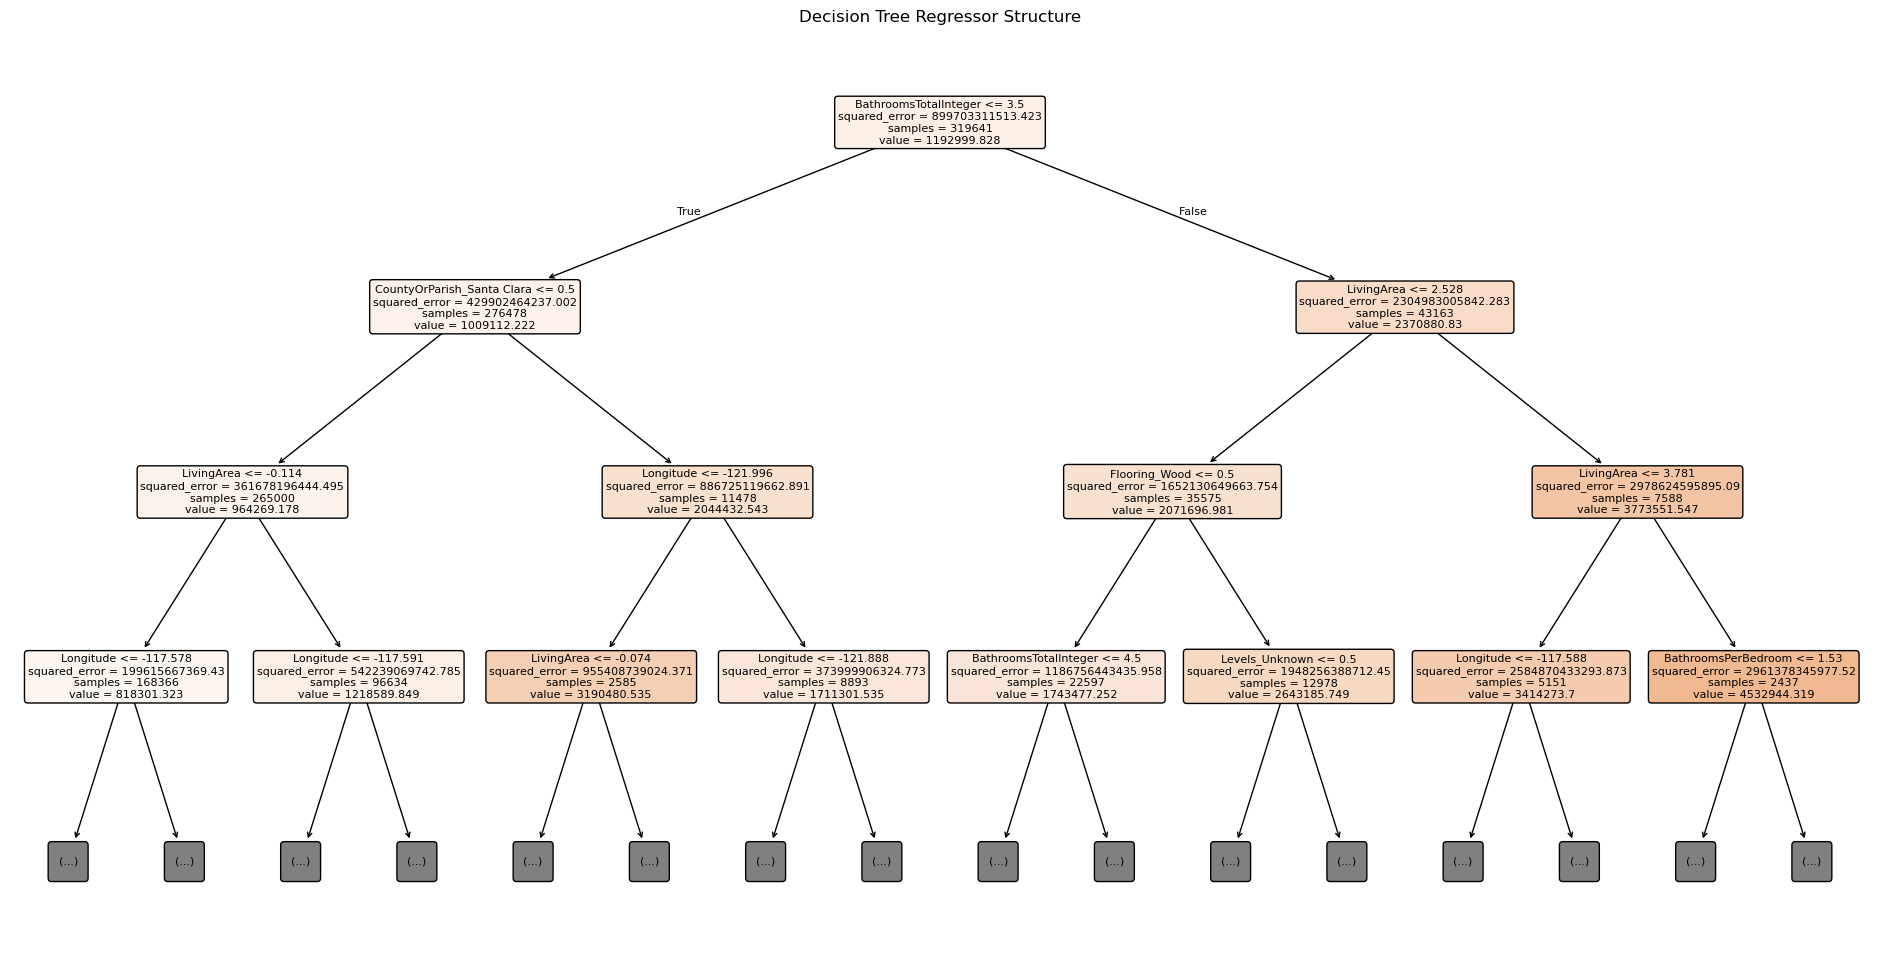

In [13]:
plt.figure(figsize = (24, 12))
plot_tree(dt_regressor, feature_names = x_train.columns, filled = True, rounded = True, max_depth = 3, fontsize = 8)
plt.title("Decision Tree Regressor Structure")
plt.show()

## Decision Tree Feature Importance

The feature importance scores below indicate the relative contribution of each feature to the Decision Tree's predictions. Higher importance values represent features that contribute more frequently to reducing prediction error during tree construction.

In [14]:
dt_feature_importance = pd.DataFrame({"Feature": x_train.columns, "Importance": dt_regressor.feature_importances_})\
    .sort_values("Importance", ascending = False).head(15)
dt_feature_importance

,Feature,Importance
10,BathroomsTotalInteger,0.265308
5,Longitude,0.174316
4,Latitude,0.156137
6,LivingArea,0.153686
86,CountyOrParish_Santa Clara,0.048957
121,Flooring_Wood,0.041874
24,LivingAreaPerBedroom,0.013461
76,CountyOrParish_Riverside,0.012892
84,CountyOrParish_San Mateo,0.011947
126,Levels_Unknown,0.009890


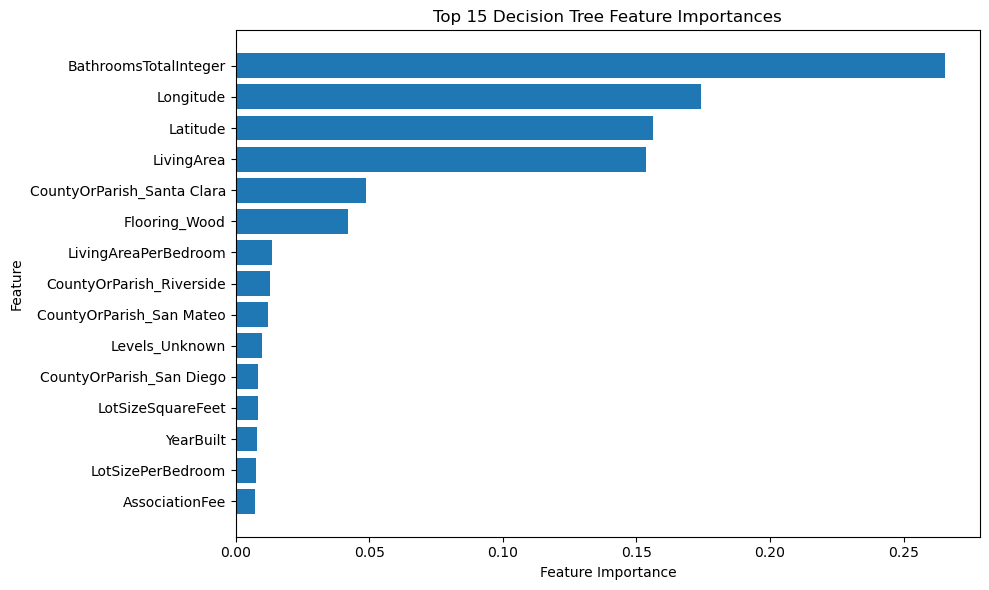

In [15]:
plt.figure(figsize = (10, 6))
plt.barh(dt_feature_importance["Feature"][::-1], dt_feature_importance["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Decision Tree Feature Importances")
plt.tight_layout()
plt.show()

## Train Random Forest Model

The Random Forest feature importance represents the average contribution of each feature across all decision trees in the ensemble. Compared with a single Decision Tree, these importance values are generally more stable and less sensitive to individual splits.

In [16]:
rf_regressor = RandomForestRegressor(
    n_estimators = 50, 
    max_depth = 15, 
    min_samples_split = 10,
    min_samples_leaf = 5,
    n_jobs = -1,
    random_state = 42
)
rf_regressor.fit(x_train, y_train)
print("Random Forest training completed.")

Random Forest training completed.


## Generate Predictions

In [17]:
y_pred_rf = rf_regressor.predict(x_test)

## Random Forest Feature Importance

In [18]:
rf_feature_importance = pd.DataFrame({"Feature": x_train.columns, "Importance": rf_regressor.feature_importances_})\
    .sort_values("Importance", ascending = False).head(15)
rf_feature_importance

,Feature,Importance
10,BathroomsTotalInteger,0.275067
5,Longitude,0.167084
6,LivingArea,0.159815
4,Latitude,0.150136
86,CountyOrParish_Santa Clara,0.050161
121,Flooring_Wood,0.042684
24,LivingAreaPerBedroom,0.015415
84,CountyOrParish_San Mateo,0.012905
76,CountyOrParish_Riverside,0.010581
126,Levels_Unknown,0.009558


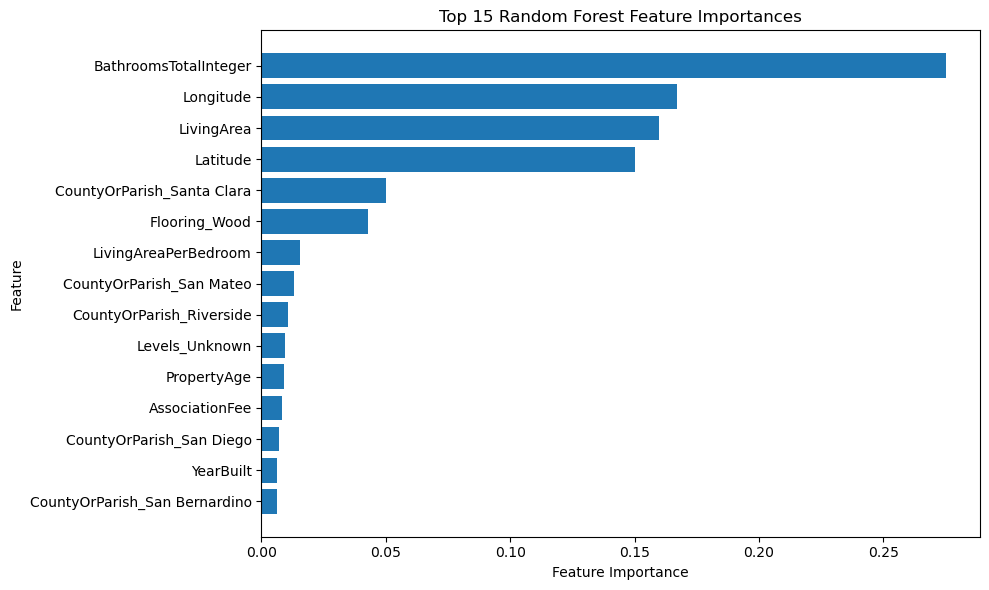

In [19]:
plt.figure(figsize = (10, 6))
plt.barh(rf_feature_importance["Feature"][::-1], rf_feature_importance["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

## Evaluate Model Performance

In [20]:
def evaluation(y_test, y_pred):
    # R-squared
    r2 = r2_score(y_test, y_pred)
    # Other results
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    rmse = root_mean_squared_error(y_test, y_pred)
    return r2, mae, mape, mdape, rmse

In [21]:
r2_dt, mae_dt, mape_dt, mdape_dt, rmse_dt = evaluation(y_test, y_pred_dt)

In [22]:
r2_rf, mae_rf, mape_rf, mdape_rf, rmse_rf = evaluation(y_test, y_pred_rf)

## Regenerate Linear Regression Results

In [23]:
lr_regressor = LinearRegression()
lr_regressor.fit(x_train, y_train)
y_pred_lr = lr_regressor.predict(x_test)
r2_lr, mae_lr, mape_lr, mdape_lr, rmse_lr = evaluation(y_test, y_pred_lr)

## Current Model Results

In [24]:
# Organize Results to dataframe
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree Regressor", "Random Forest Regressor"],
    "R²": [r2_lr, r2_dt, r2_rf],
    "MAE": [mae_lr, mae_dt, mae_rf],
    "MAPE (%)": [mape_lr, mape_dt, mape_rf],
    "MdAPE (%)": [mdape_lr, mdape_dt, mdape_rf],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf]
})
# Convert to Dataframe
results.style.format({
    "R²": "{:.4f}",
    "MAE": "${:,.2f}",
    "MAPE (%)": "{:.4f}%",
    "MdAPE (%)": "{:.4f}%",
    "RMSE": "${:,.2f}"
}).hide(axis = "index")

Model,R²,MAE,MAPE (%),MdAPE (%),RMSE
Linear Regression,0.6415,"$358,586.84",32.9718%,24.8969%,"$587,883.67"
Decision Tree Regressor,0.8198,"$208,838.71",15.4044%,10.2098%,"$416,794.21"
Random Forest Regressor,0.8602,"$191,428.79",14.9573%,10.1449%,"$367,103.45"


## Normalized Model Performance Comparison

Because the evaluation metrics use different units and scales, they cannot be compared directly on a single axis. Each metric is therefore converted into a relative performance score, where 1.0 represents the best-performing model for that metric and higher values indicate stronger performance. These normalized scores indicate relative ranking only and should not be interpreted as absolute model performance.

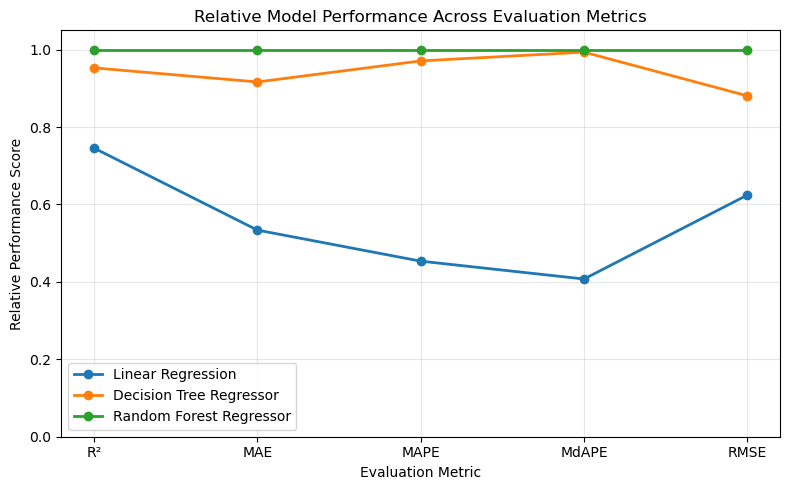

In [25]:
comparison_scores = pd.DataFrame({
    "Model": results["Model"],
    "R²": results["R²"] / results["R²"].max(),
    "MAE": results["MAE"].min() / results["MAE"],
    "MAPE": results["MAPE (%)"].min() / results["MAPE (%)"],
    "MdAPE": results["MdAPE (%)"].min() / results["MdAPE (%)"],
    "RMSE": results["RMSE"].min() / results["RMSE"]
}).set_index("Model")
plt.figure(figsize = (8, 5))
for model in comparison_scores.index:
    plt.plot(comparison_scores.columns, comparison_scores.loc[model], marker = "o", linewidth = 2, label = model)
plt.ylim(0, 1.05)
plt.ylabel("Relative Performance Score")
plt.xlabel("Evaluation Metric")
plt.title("Relative Model Performance Across Evaluation Metrics")
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Actual vs Predicted Plot

### Decision Tree

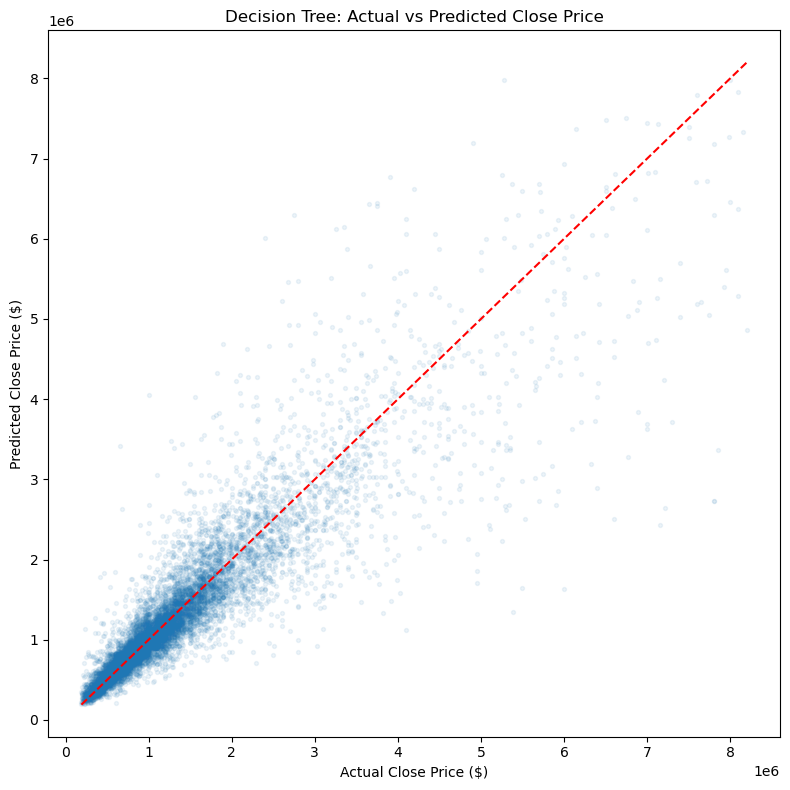

In [26]:
plt.figure(figsize = (8, 8))
plt.scatter(y_test, y_pred_dt, alpha = 0.08, s = 8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = "red", linestyle = "--")
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title("Decision Tree: Actual vs Predicted Close Price")
plt.tight_layout()
plt.show()

### Random Forest

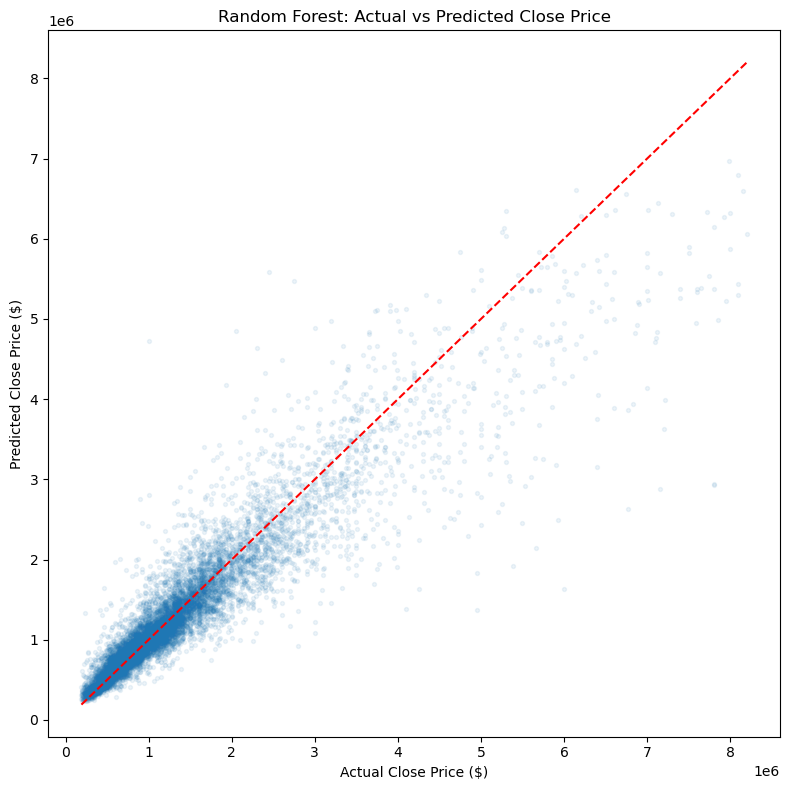

In [27]:
plt.figure(figsize = (8, 8))
plt.scatter(y_test, y_pred_rf, alpha = 0.08, s = 8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = "red", linestyle = "--")
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title("Random Forest: Actual vs Predicted Close Price")
plt.tight_layout()
plt.show()

## Previous Model Results

| Model                   |     R² |            MAE | MAPE (%) | MdAPE (%) |           RMSE |
| ----------------------- | -----: | -------------: | -------: | --------: | -------------: |
| Linear Regression       | 0.6405 | USD 368,707.93 | 33.8549% |  25.1820% | USD 586,081.35 |
| Decision Tree Regressor | 0.8130 | USD 208,460.26 | 15.1352% |   9.9675% | USD 422,718.61 |
| Random Forest Regressor | 0.8609 | USD 192,948.57 | 14.8471% |  10.1211% | USD 364,520.98 |

## Previous Evaluation Summary

The Decision Tree and Random Forest models substantially outperformed the Linear Regression baseline on the held-out testing dataset.

The Decision Tree Regressor increased the R² score from 0.6405 to 0.8130, indicating that nonlinear relationships between property characteristics and sale prices were successfully captured. Compared with the baseline, both MAE and RMSE decreased considerably, demonstrating a substantial improvement in prediction accuracy.

The Random Forest Regressor achieved the strongest overall performance, with an R² score of 0.8609, an MAE of USD 192,948.57, and an RMSE of USD 364,520.98. By aggregating predictions from multiple decision trees, the Random Forest produced more stable predictions and reduced large prediction errors compared with a single Decision Tree.

Although the Decision Tree achieved a slightly lower MdAPE than the Random Forest, the Random Forest produced the strongest overall performance based on R², MAE, and RMSE, making it the strongest candidate for subsequent feature engineering and advanced model development.

## Current Model Results

| Model | R² | MAE | MAPE (%) | MdAPE (%) | RMSE |
|---|---:|---:|---:|---:|---:|
| Linear Regression | 0.6415 | USD 358,586.84 | 32.9718% | 24.8969% | USD 587,883.67 |
| Decision Tree Regressor | 0.8198 | USD 208,838.71 | 15.4044% | 10.2098% | USD 416,794.21 |
| Random Forest Regressor | **0.8602** | **USD 191,428.79** | **14.9573%** | **10.1449%** | **USD 367,103.45** |

## Current Evaluation Summary

The current model results were generated using the revised preprocessing pipeline, updated training period, additional engineered features, and geographic information.

Overall, model performance remained broadly consistent with the original results. The Linear Regression model achieved an R² score of 0.6415, while the Decision Tree and Random Forest models achieved R² scores of 0.8198 and 0.8602, respectively.

Compared with the original Linear Regression baseline, the current model produced a slightly higher R² score and lower MAE, MAPE, and MdAPE values. RMSE increased slightly, indicating that a small number of large prediction errors remained.

The Decision Tree model also improved in R² and RMSE. However, its MAE, MAPE, and MdAPE increased slightly, suggesting that while the model explained more overall variance and reduced some large errors, its typical prediction accuracy remained similar to the original version.

The Random Forest model produced results that were very close to the original experiment. Its MAE improved slightly, while R², MAPE, MdAPE, and RMSE changed only marginally.

Among the three models, the Random Forest Regressor achieved the strongest overall performance across all reported evaluation metrics, with the highest R² and the lowest MAE, MAPE, MdAPE, and RMSE. These results confirm that ensemble tree-based methods are better able to capture nonlinear relationships and complex interactions in the property dataset than the Linear Regression baseline.

The current results establish the updated performance benchmark for future feature engineering, hyperparameter tuning, and advanced model development.

---------------------------------------------------------------------------------------------------------------------------------------------------------

## Author

Jasper Fan-Chiang

M.S. in Applied Data Science
University of Southern California

IDX Exchange — Data Science Internship